In [37]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Setup

In [43]:
# Cell 1: Imports
import os
import sys
import json
import logging
import random
import pickle
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import faiss
import itertools
import scipy.ndimage
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, roc_curve
from tqdm import tqdm


from dataset import (
    TrainDataset, TestDataset, MaskDataset,
    image_transform, efficientad_train_transform,
    denormalize, make_split, save_split, load_split,
)

from patchcore.model  import FeatureExtractor, extract_patch_features, greedy_coreset, patchify
from efficient_ad.model   import get_pdn_small, get_autoencoder, predict_map
from efficient_ad.trainer import teacher_normalization, map_normalization, train_one_step

import config

logging.basicConfig(level=logging.INFO, format='%(name)s — %(message)s')


In [3]:
SEED         = 42
DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'



torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"Device : {DEVICE}")

Device : cuda


In [56]:
DATASET_PATH = config.DATASET_PATH
TEST_DATASET_PATH = config.TEST_DATASET_PATH
TRAIN_CLS_DATASET_PATH = config.TRAIN_CLS_DATASET_PATH
MASK_DATASET_PATH = config.MASK_DATASET_PATH
TRAIN_DATASET_PATH = config.TRAIN_DATASET_PATH
SPLIT_PATH = config.SPLIT_PATH


# EDA

Train images : 280
Test categories : ['color', 'cut', 'good', 'hole', 'metal_contamination', 'thread']

Test images per category:
  color                     19
  cut                       17
  good                      28
  hole                      17
  metal_contamination       17
  thread                    19


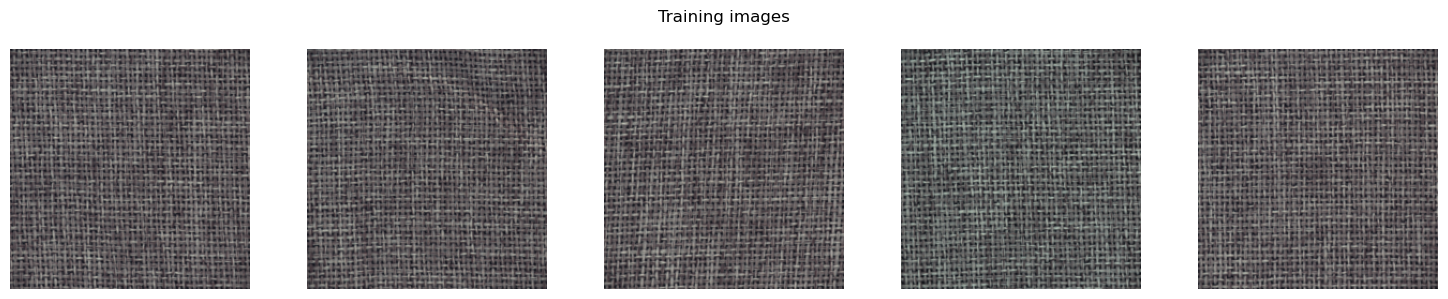

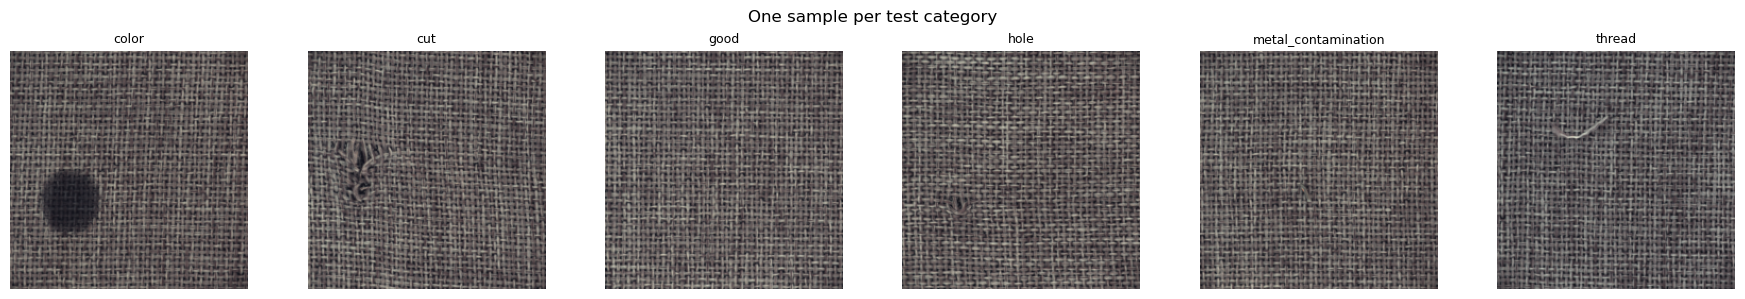

In [ ]:
# Cell 3: EDA — visualize dataset before training anything


test_categories = sorted(os.listdir(TEST_DATASET_PATH))
train_files     = os.listdir(TRAIN_CLS_DATASET_PATH)

print(f"Train images : {len(train_files)}")
print(f"Test categories : {test_categories}")

# Count test images per category
counts = {cls: len(os.listdir(f'{TEST_DATASET_PATH}/{cls}')) for cls in test_categories}
print("\nTest images per category:")
for cls, n in counts.items():
    print(f"  {cls:25s} {n}")

# Sample training images
_tfm   = image_transform(224)
_files = random.sample(train_files, 5)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle('Training images')
for ax, fname in zip(axes, _files):
    from PIL import Image as PILImage
    img = PILImage.open(f'{TRAIN_CLS_DATASET_PATH}/{fname}').convert('RGB')
    ax.imshow(denormalize(_tfm(img)).permute(1,2,0).numpy())
    ax.axis('off')
plt.tight_layout(); plt.show()

# One sample per test category
fig, axes = plt.subplots(1, len(test_categories), figsize=(3*len(test_categories), 3))
fig.suptitle('One sample per test category')
for ax, cls in zip(axes, test_categories):
    fpath = f'{TEST_DATASET_PATH}/{cls}/{sorted(os.listdir(f"{TEST_DATASET_PATH}/{cls}"))[0]}'
    img   = PILImage.open(fpath).convert('RGB')
    ax.imshow(denormalize(_tfm(img)).permute(1,2,0).numpy())
    ax.set_title(cls, fontsize=9); ax.axis('off')
plt.tight_layout(); 
plt.show()


In [9]:
# Cell 4: Create train/val split once — both models load from the same file
# Skip and go to Cell 5 if split already exists
if not os.path.exists(SPLIT_PATH):
    _full = TrainDataset(f'{DATASET_PATH}/train', transform=image_transform(224))
    train_sub, val_sub = make_split(_full, val_ratio=0.1, seed=SEED)
    save_split(train_sub, val_sub, SPLIT_PATH)
else:
    print(f"Split already exists at {SPLIT_PATH} — skipping creation")


Split saved → /ediss_data/ediss2/tmp2/anamoly-detection/results//data/split_indices.json  (train=252, val=28)


# PatchCore - Modeling

In [40]:
PC_IMAGE_SIZE = config.PC_IMAGE_SIZE
PC_BATCH_SIZE = config.PC_BATCH_SIZE
PC_LAYERS = config.PC_LAYERS
PC_PRETRAIN_DIM = config.PC_PRETRAIN_DIM
PC_TARGET_DIM = config.PC_TARGET_DIM
PC_PATCH_SIZE = config.PC_PATCH_SIZE
PC_CORESET_RATIO = config.PC_CORESET_RATIO
PC_CORESET_PROJ_DIM = config.PC_CORESET_PROJ_DIM
PC_N_NEAREST = config.PC_N_NEAREST
PC_OUTPUT_DIR = config.PC_OUTPUT_DIR
PC_MEMORY_BANK_FAISS = config.PC_MEMORY_BANK_FAISS
PC_MEMORY_BANK_NPY = config.PC_MEMORY_BANK_NPY

In [27]:
pc_train_ds = TrainDataset(TRAIN_DATASET_PATH, transform=image_transform(PC_IMAGE_SIZE))
pc_train_sub, _ = load_split(pc_train_ds, SPLIT_PATH)
pc_loader = DataLoader(pc_train_sub, batch_size=PC_BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True)

# Extract features
extractor = FeatureExtractor(layers=PC_LAYERS, device=DEVICE)
train_features, _ = extract_patch_features(
    pc_loader, extractor, PC_LAYERS, PC_PATCH_SIZE,
    PC_PRETRAIN_DIM, PC_TARGET_DIM, DEVICE,
    desc='PatchCore — extracting train features'
    )
print(f"Raw feature bank: {train_features.shape}")

    # Coreset subsampling
memory_bank = greedy_coreset(
    train_features, ratio=PC_CORESET_RATIO,
    proj_dim=PC_CORESET_PROJ_DIM, device=DEVICE)

    # Build FAISS index
pc_index = faiss.IndexFlatL2(memory_bank.shape[1])
pc_index.add(memory_bank.astype(np.float32))
print(f"FAISS index: {pc_index.ntotal} vectors ✓")

    # Save
faiss.write_index(pc_index, f'{PC_OUTPUT_DIR}/memory_bank.faiss')
np.save(f'{PC_OUTPUT_DIR}/memory_bank.npy', memory_bank)
print("---PatchCore saved---")



Split loaded ← /ediss_data/ediss2/tmp2/anamoly-detection/results//data/split_indices.json  (train=252, val=28)
Downloading: "https://download.pytorch.org/models/wide_resnet50_2-95faca4d.pth" to /home/ediss2/.cache/torch/hub/checkpoints/wide_resnet50_2-95faca4d.pth


100%|██████████| 132M/132M [00:03<00:00, 35.4MB/s] 
patchcore.model — FeatureExtractor ready — layers: ['layer2', 'layer3']
PatchCore — extracting train features: 100%|██████████| 32/32 [00:18<00:00,  1.73it/s]
patchcore.model — Extracted 197568 patch vectors


Raw feature bank: (197568, 1024)


Greedy coreset: 100%|██████████| 19756/19756 [00:05<00:00, 3831.86it/s]
patchcore.model — Coreset: 197568 → 19756 vectors (10%)


FAISS index: 19756 vectors ✓
---PatchCore saved---


# EfficientAD Modeling

In [39]:
EAD_IMAGE_SIZE   = config.EAD_IMAGE_SIZE
EAD_OUT_CHANNELS = config.EAD_OUT_CHANNELS
EAD_TRAIN_STEPS  = config.EAD_TRAIN_STEPS
EAD_BATCH_SIZE   = config.EAD_BATCH_SIZE
EAD_OUTPUT_DIR = config.EAD_OUTPUT_DIR
EAD_MODEL_PATH = config.EAD_MODEL_PATH
EAD_LR           = config.EAD_LR
EAD_WEIGHT_DECAY = config.EAD_WEIGHT_DECAY
EAD_VAL_RATIO    = config.EAD_VAL_RATIO
EAD_SEED         = config.EAD_SEED
EAD_TEACHER_PATH = config.EAD_TEACHER_PATH
EAD_STUDENT_PATH = config.EAD_STUDENT_PATH
EAD_AUTOENCODER_PATH = config.EAD_AUTOENCODER_PATH
EAD_STATS_PATH = config.EAD_STATS_PATH

Split loaded ← /ediss_data/ediss2/tmp2/anamoly-detection/results//data/split_indices.json  (train=252, val=28)


Teacher std: 100%|██████████| 252/252 [00:09<00:00, 26.66it/s]
efficient_ad.trainer — Teacher normalization complete
Map normalization: 100%|██████████| 28/28 [00:01<00:00, 19.86it/s]
efficient_ad.trainer — ST  quantiles: [0.35904, 0.51222]
efficient_ad.trainer — AE  quantiles: [0.00242, 0.00545]


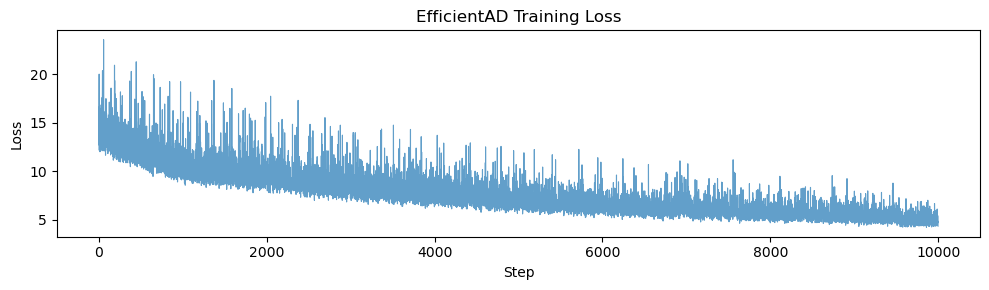

In [ ]:
ead_full_ds = TrainDataset(TRAIN_DATASET_PATH,
    transform=efficientad_train_transform(EAD_IMAGE_SIZE))
ead_train_sub, ead_val_sub = load_split(ead_full_ds, SPLIT_PATH)
ead_train_loader = DataLoader(ead_train_sub, batch_size=EAD_BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True)
ead_val_loader   = DataLoader(ead_val_sub,   batch_size=EAD_BATCH_SIZE,
    shuffle=False, num_workers=2)

def _infinite(loader):
    while True:
        for batch in loader: yield batch

teacher     = get_pdn_small(EAD_OUT_CHANNELS).to(DEVICE)
student     = get_pdn_small(2 * EAD_OUT_CHANNELS).to(DEVICE)
autoencoder = get_autoencoder(EAD_OUT_CHANNELS).to(DEVICE)

teacher.load_state_dict(torch.load(EAD_TEACHER_PATH, map_location=DEVICE))
teacher.eval()
student.train()
autoencoder.train()

t_mean, t_std = teacher_normalization(teacher, ead_train_loader, DEVICE)

optimizer = torch.optim.Adam(
    itertools.chain(student.parameters(), autoencoder.parameters()),
    lr=EAD_LR, weight_decay=EAD_WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=int(0.95 * EAD_TRAIN_STEPS), gamma=0.1)

loss_history = []
pbar = tqdm(range(EAD_TRAIN_STEPS), desc='EfficientAD training')
for step, (img_st, img_ae) in zip(pbar, _infinite(ead_train_loader)):
    img_st = img_st.to(DEVICE)
    img_ae = img_ae.to(DEVICE)

    loss = train_one_step(teacher, student, autoencoder, img_st, img_ae, t_mean, t_std,
        EAD_OUT_CHANNELS, optimizer)
    scheduler.step()
    loss_history.append(loss)
    if step % 100 == 0:
        pbar.set_description(f"EfficientAD loss: {loss:.4f}")

    # Map normalization on val set
q_st_start, q_st_end, q_ae_start, q_ae_end = map_normalization(
    ead_val_loader, teacher, student, autoencoder,
    t_mean, t_std, EAD_OUT_CHANNELS, DEVICE
)

torch.save(student.state_dict(), f'{EAD_MODEL_PATH}/student_final.pth')
torch.save(autoencoder.state_dict(), f'{EAD_MODEL_PATH}/autoencoder_final.pth')
torch.save({'mean': t_mean, 'std': t_std,
    'q_st_start': q_st_start, 'q_st_end': q_st_end,
    'q_ae_start': q_ae_start, 'q_ae_end': q_ae_end},
    f'{EAD_MODEL_PATH}/stats.pth')

# Loss curve
plt.figure(figsize=(10, 3))
plt.plot(loss_history, linewidth=0.8, alpha=0.7)
plt.xlabel('Step'); plt.ylabel('Loss')
plt.title('EfficientAD Training Loss')
plt.tight_layout(); plt.show()

# Evaluate

In [ ]:
from patchcore.inference import run_inference as pc_inference

pc_results = pc_inference(
    test_dataset_path = TEST_DATASET_PATH,
    mask_dataset_path = MASK_DATASET_PATH,
    index_path        = PC_MEMORY_BANK_FAISS,
    device            = DEVICE,
)

# Unpack for visualization
pc_y_true       = pc_results['y_true'] 
pc_classes_list = pc_results['classes']
pc_masks_gt_np  = pc_results['masks']
pc_scores    = pc_results['scores']
pc_maps      = pc_results['maps']


patchcore.inference — Test set: 117 images | Classes: ['color', 'cut', 'good', 'hole', 'metal_contamination', 'thread']
patchcore.inference — Memory bank: 19756 vectors
patchcore.model — FeatureExtractor ready — layers: ['layer2', 'layer3']
PatchCore inference: 100%|██████████| 117/117 [00:50<00:00,  2.30it/s]
patchcore.inference — Inference complete
eval — Image AUROC: 99.16%
eval — Full pixel AUROC: 99.12%
eval — Anomaly-only pixel AUROC: 98.87%
patchcore.inference — Per-class image AUROC:
eval —   color                     AUROC: 100.00%
eval —   cut                       AUROC: 100.00%
eval —   hole                      AUROC: 100.00%
eval —   metal_contamination       AUROC: 96.85%
eval —   thread                    AUROC: 98.87%


Model                Image AUROC     Full Pixel AUROC  Anomaly Pixel AUROC
--------------------------------------------------------------------------
PatchCore                  99.16%                99.12%                98.87%


In [64]:
from efficient_ad.inference import run_inference as ead_inference

ead_results = ead_inference(
    test_dataset_path = TEST_DATASET_PATH,
    mask_dataset_path = MASK_DATASET_PATH,
    device            = DEVICE,
)

# Unpack for visualization — y_true and masks already match pc_results
ead_scores = ead_results['scores']
ead_maps   = ead_results['maps']
ead_y_true       = ead_results['y_true'] 
ead_classes_list = ead_results['classes']
ead_masks_gt_np  = ead_results['masks']


efficient_ad.inference — Test set: 117 images | Classes: ['color', 'cut', 'good', 'hole', 'metal_contamination', 'thread']
efficient_ad.model — Teacher loaded from /ediss_data/ediss2/tmp2/anamoly-detection/models/efficient_ad/teacher_small.pth
EfficientAD inference: 100%|██████████| 117/117 [00:05<00:00, 19.96it/s]
efficient_ad.inference — Inference complete
metrics — Image AUROC: 96.47%
metrics — Full pixel AUROC: 95.69%
metrics — Anomaly-only pixel AUROC: 96.19%
efficient_ad.inference — Per-class image AUROC:
metrics —   color                     AUROC: 92.11%
metrics —   cut                       AUROC: 100.00%
metrics —   hole                      AUROC: 97.69%
metrics —   metal_contamination       AUROC: 100.00%
metrics —   thread                    AUROC: 93.42%


Model                  Image AUROC     Full Pixel AUROC  Anomaly Pixel AUROC
----------------------------------------------------------------------------
EfficientAD                  96.47%                95.69%                96.19%
